In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

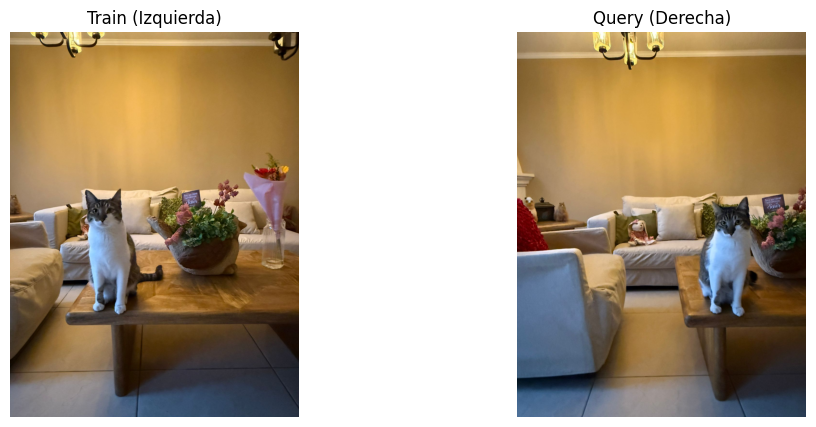

In [10]:
img_train = cv2.imread("left.jpeg")   # Imagen Izquierda (Base)
img_query = cv2.imread("right.jpeg")  # Imagen Derecha (Mover)

# Convertir a RGB para visualizar con matplotlib
img_train_rgb = cv2.cvtColor(img_train, cv2.COLOR_BGR2RGB)
img_query_rgb = cv2.cvtColor(img_query, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.title("Train (Izquierda)")
plt.imshow(img_train_rgb)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Query (Derecha)")
plt.imshow(img_query_rgb)
plt.axis("off")
plt.show()

In [11]:
orb = cv2.ORB_create(4000)

kp1, des1 = orb.detectAndCompute(img_train, None)
kp2, des2 = orb.detectAndCompute(img_query, None)

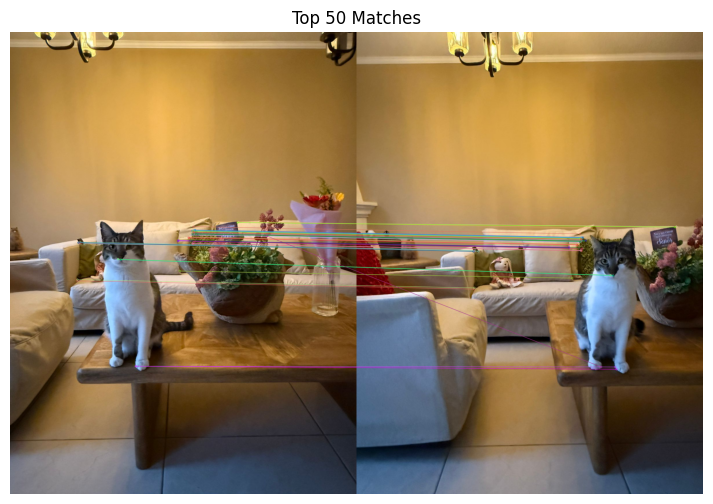

In [12]:
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches = bf.match(des1, des2)

matches = sorted(matches, key=lambda x: x.distance)

# Visualizar matches
img_matches = cv2.drawMatches(img_train, kp1,
                              img_query, kp2,
                              matches[:50], None,
                              flags=2)

plt.figure(figsize=(15,6))
plt.imshow(cv2.cvtColor(img_matches, cv2.COLOR_BGR2RGB))
plt.title("Top 50 Matches")
plt.axis("off")
plt.show()

In [13]:
pts_train = np.float32([kp1[m.queryIdx].pt for m in matches]).reshape(-1,1,2)
pts_query = np.float32([kp2[m.trainIdx].pt for m in matches]).reshape(-1,1,2)

H, mask = cv2.findHomography(pts_query, pts_train, cv2.RANSAC, 5.0)

print("Homografía:\n", H)

Homografía:
 [[ 1.04827019e+00 -1.92296978e-01 -5.73536969e+01]
 [ 7.63783589e-02  8.60659501e-01 -1.15700103e+00]
 [ 9.09059641e-05 -1.33327540e-04  1.00000000e+00]]


La matriz de homografía estimada presenta componentes proyectivas pequeñas (del orden de 10⁻⁴), lo que indica estabilidad geométrica. La traslación horizontal estimada fue de aproximadamente 57 píxeles, consistente con el movimiento realizado durante la captura.